In [2]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [4]:
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

column_names = [
    "MPG", "Cylinders", "Displacement", "Horsepower",
    "Weight", "Acceleration", "Model Year", "Origin", "Car Name"
]

df = pd.read_csv(
    url,
    names=column_names,
    na_values="?",
    comment="\t",
    sep=r"\s+",
    skipinitialspace=True
)

df.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car Name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [5]:
print(df.shape)
print(df.isna().sum())

df = df.dropna().reset_index(drop=True)

print("After dropping missing rows:", df.shape)
df.head()

(398, 9)
MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
Car Name        0
dtype: int64
After dropping missing rows: (392, 9)


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car Name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [6]:
origin_dummies = pd.get_dummies(df["Origin"], prefix="Origin")
df = pd.concat([df.drop(columns=["Origin", "Car Name"]), origin_dummies], axis=1)

df.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin_1,Origin_2,Origin_3
0,18.0,8,307.0,130.0,3504.0,12.0,70,True,False,False
1,15.0,8,350.0,165.0,3693.0,11.5,70,True,False,False
2,18.0,8,318.0,150.0,3436.0,11.0,70,True,False,False
3,16.0,8,304.0,150.0,3433.0,12.0,70,True,False,False
4,17.0,8,302.0,140.0,3449.0,10.5,70,True,False,False


In [7]:
X = df.drop(columns=["MPG"]).values.astype(np.float32)
y = df["MPG"].values.astype(np.float32).reshape(-1, 1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)

Train shape: (313, 9) (313, 1)
Val shape: (79, 9) (79, 1)


In [8]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [9]:
input_dim = X_train.shape[1]

class RegressionNet1(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1)
        )

    def forward(self, x):
        return self.net(x)


class RegressionNet2(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Linear(10, 20),
            nn.ReLU(),
            nn.Linear(20, 10),
            nn.ReLU(),
            nn.Linear(10, 1)
        )

    def forward(self, x):
        return self.net(x)


class RegressionNet3(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Linear(10, 20),
            nn.ReLU(),
            nn.Linear(20, 30),
            nn.ReLU(),
            nn.Linear(30, 20),
            nn.ReLU(),
            nn.Linear(20, 1)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def train_regression_model(model, train_loader, val_loader, epochs=20, lr=0.01):
    model = model.to(device)
    criterion = nn.MSELoss()
    # optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch)
                loss = criterion(preds, y_batch)
                running_val_loss += loss.item() * X_batch.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        print(
            f"Epoch [{epoch+1:02d}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f}"
        )

    total_time = time.time() - start_time
    return model, train_losses, val_losses, total_time

In [11]:
results_regression = {}

models_regression = {
    "Network 1": RegressionNet1(input_dim),
    "Network 2": RegressionNet2(input_dim),
    "Network 3": RegressionNet3(input_dim),
}

for name, model in models_regression.items():
    print(f"\nTraining {name}")
    trained_model, train_losses, val_losses, train_time = train_regression_model(
        model, train_loader, val_loader, epochs=20, lr=0.01
    )

    results_regression[name] = {
        "model": trained_model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_time_sec": train_time,
        "final_val_loss": val_losses[-1]
    }


Training Network 1
Epoch [01/20] | Train Loss: 523.9110 | Val Loss: 361.4804
Epoch [02/20] | Train Loss: 338.5152 | Val Loss: 240.0610
Epoch [03/20] | Train Loss: 228.6179 | Val Loss: 162.4659
Epoch [04/20] | Train Loss: 157.0525 | Val Loss: 110.9247
Epoch [05/20] | Train Loss: 108.6591 | Val Loss: 77.0446
Epoch [06/20] | Train Loss: 76.6639 | Val Loss: 54.7939
Epoch [07/20] | Train Loss: 55.2181 | Val Loss: 39.7519
Epoch [08/20] | Train Loss: 40.8425 | Val Loss: 30.2111
Epoch [09/20] | Train Loss: 31.4021 | Val Loss: 23.7708
Epoch [10/20] | Train Loss: 25.0315 | Val Loss: 19.5473
Epoch [11/20] | Train Loss: 20.7229 | Val Loss: 16.8710
Epoch [12/20] | Train Loss: 17.8493 | Val Loss: 15.1726
Epoch [13/20] | Train Loss: 15.8676 | Val Loss: 13.6791
Epoch [14/20] | Train Loss: 14.5941 | Val Loss: 12.9640
Epoch [15/20] | Train Loss: 13.7085 | Val Loss: 12.6718
Epoch [16/20] | Train Loss: 13.1460 | Val Loss: 12.2881
Epoch [17/20] | Train Loss: 12.7287 | Val Loss: 12.0784
Epoch [18/20] | Tra

In [12]:
summary_rows = []
for name, info in results_regression.items():
    summary_rows.append({
        "Model": name,
        "Final Train Loss": info["train_losses"][-1],
        "Final Validation Loss": info["final_val_loss"],
        "Training Time (sec)": info["train_time_sec"]
    })

regression_summary = pd.DataFrame(summary_rows).sort_values(by="Final Validation Loss")
regression_summary

,Model,Final Train Loss,Final Validation Loss,Training Time (sec)
0,Network 1,12.109140,11.884711,0.144333
1,Network 2,18.153863,16.878002,0.207685
2,Network 3,NaN,NaN,0.212522


In [13]:
best_regression_model = regression_summary.iloc[0]["Model"]
best_regression_error = regression_summary.iloc[0]["Final Validation Loss"]

print(f"Best regression model: {best_regression_model}")
print(f"Lowest validation error: {best_regression_error:.4f}")

Best regression model: Network 1
Lowest validation error: 11.8847


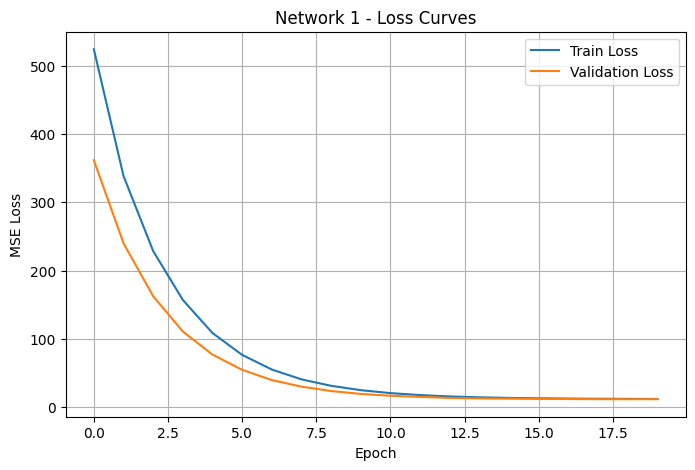

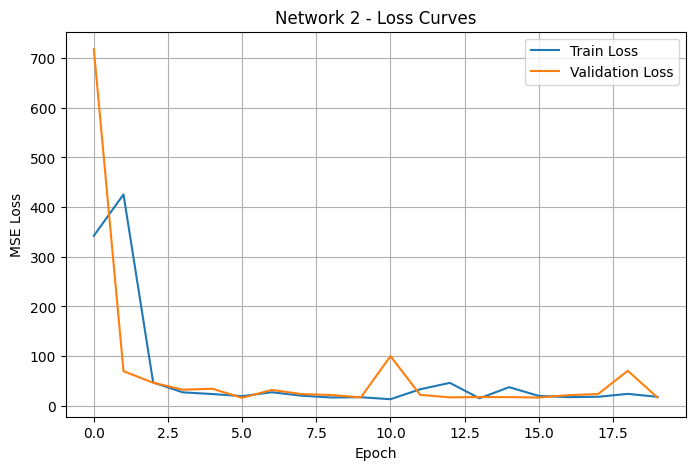

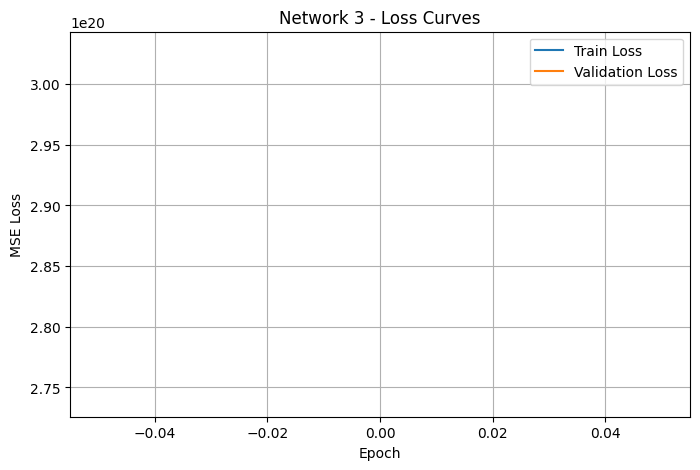

In [14]:
for name, info in results_regression.items():
    plt.figure(figsize=(8, 5))
    plt.plot(info["train_losses"], label="Train Loss")
    plt.plot(info["val_losses"], label="Validation Loss")
    plt.title(f"{name} - Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

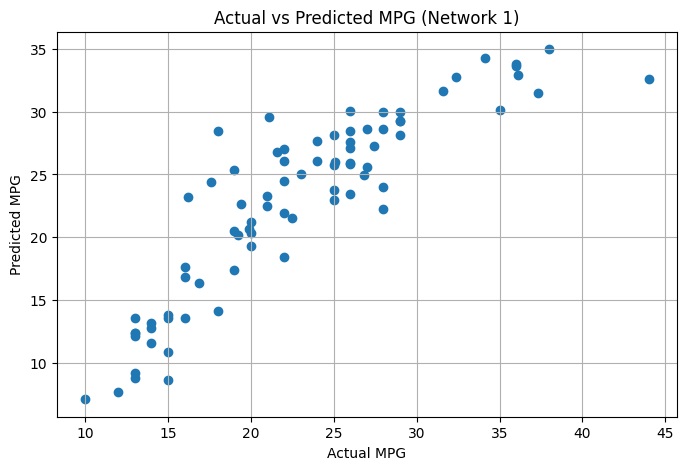

In [15]:
best_model = results_regression[best_regression_model]["model"]
best_model.eval()

with torch.no_grad():
    y_val_pred = best_model(X_val_tensor.to(device)).cpu().numpy()

plt.figure(figsize=(8, 5))
plt.scatter(y_val, y_val_pred)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title(f"Actual vs Predicted MPG ({best_regression_model})")
plt.grid(True)
plt.show()

In [16]:
print("Answer:")
print(f"The model with the least validation error was {best_regression_model} "
      f"with validation loss = {best_regression_error:.4f}.")

Answer:
The model with the least validation error was Network 1 with validation loss = 11.8847.
